GPU is available
Using device: NVIDIA GeForce RTX 3090
Training with hidden_channels=128, learning_rate=0.001, weight_decay=1e-05, epochs=200
Epoch 10/200, Loss: 0.0475
Epoch 20/200, Loss: 0.0352
Epoch 30/200, Loss: 0.0291
Epoch 40/200, Loss: 0.0284
Epoch 50/200, Loss: 0.0283
Epoch 60/200, Loss: 0.0283
Epoch 70/200, Loss: 0.0283
Epoch 80/200, Loss: 0.0283
Epoch 90/200, Loss: 0.0282
Epoch 100/200, Loss: 0.0282
Epoch 110/200, Loss: 0.0282
Epoch 120/200, Loss: 0.0282
Epoch 130/200, Loss: 0.0282
Early stopping at epoch 130


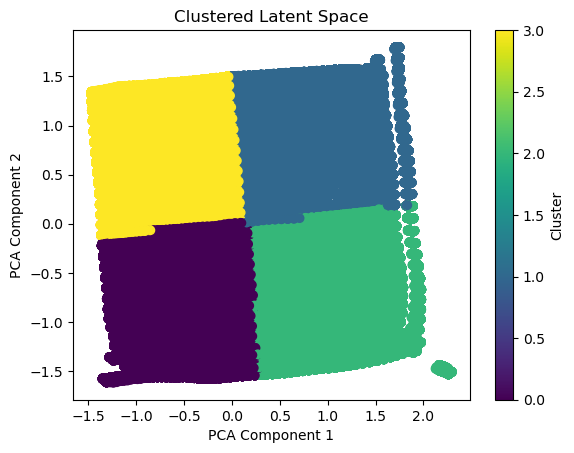

In [4]:
import os
import time
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, VGAE
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import datetime
from sklearn.model_selection import KFold

if torch.cuda.is_available():
    print("GPU is available")
    print(f"Using device: {torch.cuda.get_device_name(0)}")
else:
    print("GPU is not available, using CPU")
    
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# Random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Data paths
standardized_data_folder = "/home/nishioka/GNN/Defect_4x4_Normalized1"
label_data_folder = "/home/nishioka/GNN/Defectlabel4x4/DefectLabels_4x4_test1"

# Load coordinate data
x_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/x_2layer_normalized.npy")[:3654]
y_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/y_2layer_normalized.npy")[:3654]
z_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/z_2layer_normalized.npy")[:3654]

# Load edge information
edges = np.load("/home/nishioka/GNN/BasicdataforGNN/edges_2layer.npy")
edge_index = torch.tensor(edges.T, dtype=torch.long).to(device)

# Data and label files
data_files = [f for f in os.listdir(standardized_data_folder) if f.startswith("Normalized1_Defect4x4_ELNOD")]
label_files = [f for f in os.listdir(label_data_folder) if f.startswith("DefectLabel_L")]

# Function to extract layer and block information from filenames
def extract_layer_block(file_name):
    if file_name.startswith("0"):
        return (0, 0)  # No defect data
    try:
        layer_block_str = file_name.split("_")[-1].replace(".npy", "")
        layer_str = layer_block_str.split("L")[1].split("B")[0]
        block_str = layer_block_str.split("B")[1]
        layer = int(layer_str)
        block = int(block_str)
        return (layer, block)
    except (ValueError, IndexError):
        print(f"Invalid file name format: {file_name}")
        return None

# Prepare data pairs
data_label_pairs = {}
for data_file in data_files:
    layer_block = extract_layer_block(data_file)
    if layer_block:
        data_label_pairs[layer_block] = {"data": data_file}

for label_file in label_files:
    layer_block = extract_layer_block(label_file)
    if layer_block and layer_block in data_label_pairs:
        data_label_pairs[layer_block]["label"] = label_file

# Valid pairs and adding defect-free data
valid_pairs = [(v["data"], v["label"]) for k, v in data_label_pairs.items() if "label" in v]
defect_free_pair = ("/home/nishioka/GNN/BasicdataforGNN/Normalized1_nodefect_ElNOD.npy",
                    "/home/nishioka/GNN/BasicdataforGNN/DefectLabel_nodefect.npy")
for _ in range(100):
    valid_pairs.append(defect_free_pair)

# Prepare data
def prepare_data(pairs):
    sampled_data = []
    sampled_labels = []
    
    for data_file, label_file in pairs:
        data_file_path = os.path.join(standardized_data_folder, data_file)
        label_file_path = os.path.join(label_data_folder, label_file)

        # Load data and labels
        try:
            values = np.load(data_file_path)[:3654]
            label = np.load(label_file_path)[:3654]
        except Exception as e:
            print(f"Error loading data: {e}")
            continue
        
        # Create node features by combining coordinate and stress data
        node_features = np.vstack((x_coords, y_coords, z_coords, values)).T
        sampled_data.append(node_features)
        sampled_labels.append(label)
    
    if len(sampled_data) == 0 or len(sampled_labels) == 0:
        print("No valid data found in the pairs.")
        return None

    # Convert to tensor
    sampled_data = np.stack(sampled_data)
    sampled_labels = np.hstack(sampled_labels)

    x = torch.tensor(sampled_data.reshape(-1, 4), dtype=torch.float).to(device)
    y = torch.tensor(sampled_labels, dtype=torch.float).to(device)

    return x, y

all_x, all_y = prepare_data(valid_pairs)

# Create Data objects for each sample
all_data_list = []
num_all_samples = all_x.shape[0] // 3654
for i in range(num_all_samples):
    all_data_list.append(Data(x=all_x[i * 3654:(i + 1) * 3654], edge_index=edge_index, y=all_y[i * 3654:(i + 1) * 3654]))

# Use DataLoader for memory efficiency
batch_size = 32
train_data, test_data = train_test_split(all_data_list, test_size=0.2, random_state=42)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

# Define GVAE model class
class Encoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super(Encoder, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)  # Batch Normalization
        self.dropout = nn.Dropout(p=0.3)  # Dropout
        self.conv2 = GCNConv(hidden_channels, hidden_channels * 2)
        self.conv_mu = GCNConv(hidden_channels * 2, hidden_channels)
        self.conv_logstd = GCNConv(hidden_channels * 2, hidden_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logstd(x, edge_index)

class Decoder(torch.nn.Module):
    def __init__(self, hidden_channels, out_channels):
        super(Decoder, self).__init__()
        self.linear = nn.Linear(hidden_channels, out_channels)

    def forward(self, z):
        return self.linear(z)

# Training with hyperparameters and early stopping
hidden_channels_list = [128]
learning_rate_list = [1e-3]
weight_decay_list = [1e-5]
epochs_list = [200]
patience = 10  # Early stopping patience
best_loss = float('inf')
epochs_no_improve = 0

# Grid search over all combinations of hyperparameters
for hidden_channels in hidden_channels_list:
    for learning_rate in learning_rate_list:
        for weight_decay in weight_decay_list:
            for epochs in epochs_list:
                print(f"Training with hidden_channels={hidden_channels}, learning_rate={learning_rate}, weight_decay={weight_decay}, epochs={epochs}")
                
                encoder = Encoder(in_channels=4, hidden_channels=hidden_channels).to(device)
                decoder = Decoder(hidden_channels=hidden_channels, out_channels=4).to(device)
                model = VGAE(encoder).to(device)
                optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=learning_rate, weight_decay=weight_decay)
                scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)  # Learning rate scheduler

                def loss_fn(recon_x, x, mu, logstd):
                    recon_loss = F.mse_loss(recon_x, x, reduction='mean')
                    kl_divergence = -0.5 * torch.mean(1 + 2 * logstd - mu.pow(2) - (2 * logstd).exp())
                    return recon_loss + kl_divergence

                for epoch in range(1, epochs + 1):
                    model.train()
                    total_loss = 0
                    for data in train_loader:
                        data = data.to(device)
                        optimizer.zero_grad()
                
                        # VGAE modelにデータを直接渡す
                        z = model.encode(data.x, data.edge_index)  # VGAEのエンコードで潜在変数zを取得
                        recon = decoder(z)  # 潜在変数zをデコーダに渡して再構成
                
                        # エンコーダからの出力で損失関数を計算
                        mu, logstd = model.__mu__, model.__logstd__  # VGAEが内部で持っている属性を使用
                        loss = loss_fn(recon, data.x, mu, logstd)
                        
                        loss.backward()
                        optimizer.step()
                        total_loss += loss.item()
                
                    avg_loss = total_loss / len(train_loader)
                    scheduler.step()  # 学習率の更新
                
                    if epoch % 10 == 0:
                        print(f"Epoch {epoch}/{epochs}, Loss: {avg_loss:.4f}")
                
                    # Early stopping のチェック
                    if avg_loss < best_loss:
                        best_loss = avg_loss
                        epochs_no_improve = 0
                        torch.save(model.state_dict(), f'/home/nishioka/GNN/GNNmodel/gvae_model_best_{timestamp}.pth')
                    else:
                        epochs_no_improve += 1
                
                    if epochs_no_improve >= patience:
                        print(f"Early stopping at epoch {epoch}")
                        break

model.eval()
z_encoded = []
with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        
        # VGAEのencodeメソッドを使って潜在変数zを取得
        z = model.encode(data.x, data.edge_index)  # VGAEが自動でreparameterizeを行う
        
        z_encoded.append(z.cpu().numpy())  # 潜在変数をnumpyに変換して格納

# z_encodedをnumpy配列に変換
z_encoded = np.vstack(z_encoded)

# Clustering the encoded latent space
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(z_encoded)

# Visualizing the clusters using PCA for dimensionality reduction
pca = PCA(n_components=2)
z_pca = pca.fit_transform(z_encoded)
plt.scatter(z_pca[:, 0], z_pca[:, 1], c=clusters, cmap='viridis')
plt.title('Clustered Latent Space')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.savefig(f'/home/nishioka/GNN/GNNmodelgraphfig/gvae_cluster_{timestamp}.png')
plt.show()

# Using clustered data to train GNN model
# Here you would use `clusters` as labels or input for the next GNN training.


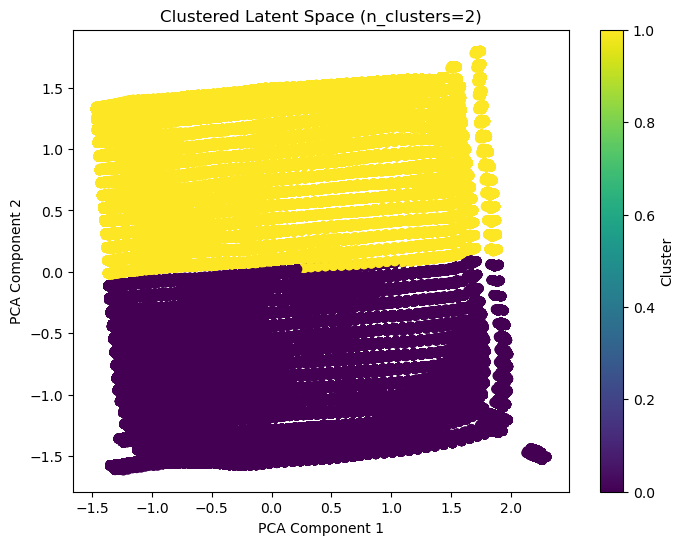

In [10]:
import os
import time
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, VGAE
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import datetime
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Assuming model is trained and we have test_loader for evaluation

model.eval()
z_encoded = []
with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        z = model.encode(data.x, data.edge_index)
        z_encoded.append(z.cpu().numpy())

# Convert the latent space list into a numpy array
z_encoded = np.vstack(z_encoded)

# Apply KMeans clustering with n_clusters=2
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(z_encoded)

# Reduce dimensions with PCA for visualization
pca = PCA(n_components=2)
z_pca = pca.fit_transform(z_encoded)

# Plot the clustered latent space
plt.figure(figsize=(8, 6))
plt.scatter(z_pca[:, 0], z_pca[:, 1], c=clusters, cmap='viridis')
plt.title('Clustered Latent Space (n_clusters=2)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()



In [ ]:
# Convert the latent space list into a numpy array
z_encoded = np.vstack(z_encoded)

# Reduce the dataset size for faster visualization
sample_size = 1000  # Adjust this value as needed
z_encoded_sample = z_encoded[np.random.choice(z_encoded.shape[0], sample_size, replace=False)]

# Apply t-SNE and UMAP on the sampled data
tsne = TSNE(n_components=2, random_state=42)
z_tsne_sample = tsne.fit_transform(z_encoded_sample)

umap_model = umap.UMAP(n_components=2, random_state=42)
z_umap_sample = umap_model.fit_transform(z_encoded_sample)

# Plot both t-SNE and UMAP results
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(z_tsne_sample[:, 0], z_tsne_sample[:, 1], c='blue', alpha=0.5)
plt.title('Latent Space with t-SNE')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

plt.subplot(1, 2, 2)
plt.scatter(z_umap_sample[:, 0], z_umap_sample[:, 1], c='blue', alpha=0.5)
plt.title('Latent Space with UMAP')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')

plt.tight_layout()
plt.show()


# Apply t-SNE for 2D visualization
tsne = TSNE(n_components=2, random_state=42)
z_tsne = tsne.fit_transform(z_encoded)

# Apply UMAP for 2D visualization
umap_model = umap.UMAP(n_components=2, random_state=42)
z_umap = umap_model.fit_transform(z_encoded)

# Plot both t-SNE and UMAP results in a single figure with subplots
plt.figure(figsize=(12, 6))

# t-SNE subplot
plt.subplot(1, 2, 1)
plt.scatter(z_tsne[:, 0], z_tsne[:, 1], c='blue', alpha=0.5)
plt.title('Latent Space with t-SNE')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

# UMAP subplot
plt.subplot(1, 2, 2)
plt.scatter(z_umap[:, 0], z_umap[:, 1], c='blue', alpha=0.5)
plt.title('Latent Space with UMAP')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')

# Show the plots
plt.tight_layout()
plt.show()


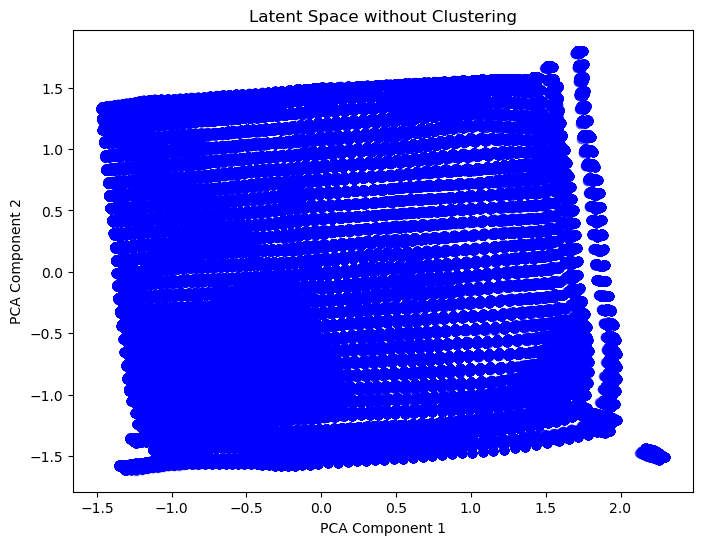

In [5]:
import matplotlib.pyplot as plt
# クラスタリングなしのPCAによる潜在空間の可視化
plt.figure(figsize=(8, 6))

# クラスタなしで潜在空間をそのままプロット
plt.scatter(z_pca[:, 0], z_pca[:, 1], c='b', alpha=0.5)  # 全て同じ色でプロット
plt.title('Latent Space without Clustering')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()


In [20]:
import os
import time
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, VGAE
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import datetime
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap


model.eval()
z_encoded = []
with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        z = model.encode(data.x, data.edge_index)
        z_encoded.append(z.cpu().numpy())

# Convert the latent space list into a numpy array
z_encoded = np.vstack(z_encoded)

# Apply t-SNE for 2D visualization
tsne = TSNE(n_components=2, random_state=42)
z_tsne = tsne.fit_transform(z_encoded)

# Plot the t-SNE result
plt.figure(figsize=(8, 6))
plt.scatter(z_tsne[:, 0], z_tsne[:, 1], c='blue', alpha=0.5)
plt.title('Latent Space with t-SNE')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()


# Apply UMAP for 2D visualization
umap_model = umap.UMAP(n_components=2, random_state=42)
z_umap = umap_model.fit_transform(z_encoded)

# Plot the UMAP result
plt.figure(figsize=(8, 6))
plt.scatter(z_umap[:, 0], z_umap[:, 1], c='blue', alpha=0.5)
plt.title('Latent Space with UMAP')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.show()

ModuleNotFoundError: No module named 'umap'

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming z_encoded, z_pca, and original_data are available
# Step 1: Retrieve the indices of the points in the lower right corner of the PCA plot

# Identify the points in the lower right corner
right_corner_indices = np.where((z_pca[:, 0] > 2) & (z_pca[:, 1] < -1.5))

# Step 2: Print the indices and the corresponding latent space data
print("Indices of points in the lower right corner:")
# for idx in right_corner_indices[0]:
    # print(f"Index: {idx}, Latent Space Data: {z_encoded[idx]}")

# Step 3: Assuming original_data is the input data to the GNN model (the node features), we can retrieve the original data points

# Print the corresponding original data points for the identified indices
print("\nCorresponding original data points:")
# for idx in right_corner_indices[0]:
    # print(f"Index: {idx}, Original Data Features: {original_data[idx]}")

# Step 4: Visualize the original data to see how the right corner points differ from the rest

# Assuming original_data is a NumPy array and we visualize the first feature of the original data
plt.figure(figsize=(8, 6))
plt.scatter(np.arange(len(original_data)), original_data[:, 0], label='All Data')
plt.scatter(right_corner_indices, original_data[right_corner_indices, 0], color='red', label='Right Corner Points')
plt.xlabel('Data Index')
plt.ylabel('Feature Value (Feature 1)')
plt.title('Original Data Feature 1 with Right Corner Points Highlighted')
plt.legend()
plt.show()


Indices of points in the lower right corner:

Corresponding original data points:


NameError: name 'original_data' is not defined

<Figure size 800x600 with 0 Axes>

In [12]:
# Assuming z_encoded is the latent space data
# Step 1: Check the total number of points in the latent space
total_points = len(z_encoded)  # Total number of latent space points

# Step 2: Print the total number of points
print(f"Total number of points in the latent space: {total_points}")

# Step 3: Filtering and displaying only a limited number of latent space dimensions for the specific index
index = 1857
latent_space_data = z_encoded[index]

# Display only the first 10 dimensions of the latent space for clarity
filtered_latent_space_data = latent_space_data[:10]

# Print the filtered latent space data
print(f"Filtered Latent Space Data for index {index} (first 10 dimensions): {filtered_latent_space_data}")


Total number of points in the latent space: 1256976
Filtered Latent Space Data for index 1857 (first 10 dimensions): [-0.00013082  0.00065474  0.00450439 -0.00420182 -0.00648069  0.00343477
 -0.00252876 -0.00103697 -0.00245401 -0.00360172]


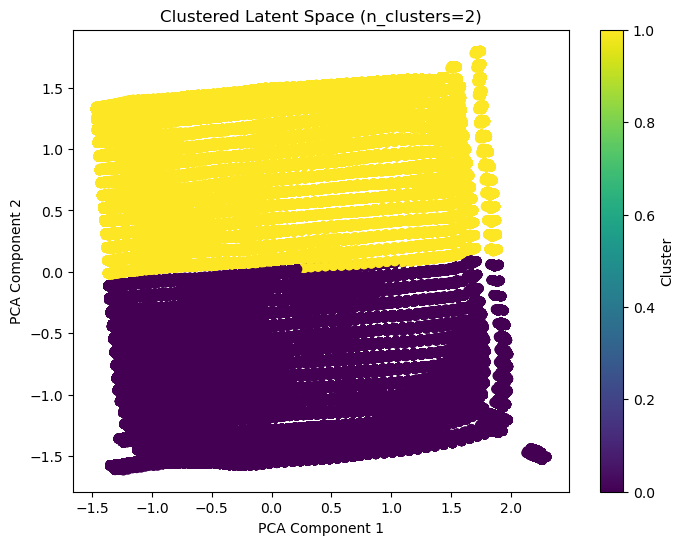

In [21]:
import os
import time
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, VGAE
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import datetime
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Assuming model is trained and we have test_loader for evaluation

model.eval()
z_encoded = []
with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        z = model.encode(data.x, data.edge_index)
        z_encoded.append(z.cpu().numpy())

# Convert the latent space list into a numpy array
z_encoded = np.vstack(z_encoded)

# Apply KMeans clustering with n_clusters=2
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(z_encoded)

# Reduce dimensions with PCA for visualization
pca = PCA(n_components=3)
z_pca = pca.fit_transform(z_encoded)

# Plot the clustered latent space
plt.figure(figsize=(8, 6))
plt.scatter(z_pca[:, 0], z_pca[:, 1], c=clusters, cmap='viridis')
plt.title('Clustered Latent Space (n_clusters=2)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()

In [13]:
# Assuming you have a DataLoader or dataset prepared earlier
# Here, we simulate loading the data into all_data_list

# Load or generate your dataset (modify according to your actual data source)
all_data_list = []  # This should contain your list of graphs

# Ensure you have loaded your data into all_data_list
if len(all_data_list) == 0:
    print("Error: No data found in all_data_list. Please check your dataset.")
else:
    # Step 1: Check the total number of graphs and nodes in each graph
    num_graphs = len(all_data_list)

    # Check the number of nodes in each graph and sum them
    num_nodes_per_graph = [data.x.shape[0] for data in all_data_list]  # List of node counts per graph
    total_nodes = sum(num_nodes_per_graph)  # Total number of nodes across all graphs

    # Step 2: Print the total number of graphs and total number of nodes
    print(f"Total number of graphs: {num_graphs}")
    print(f"Total number of nodes across all graphs: {total_nodes}")

    # Step 3: Check the average number of nodes per graph for better understanding
    average_nodes_per_graph = total_nodes / num_graphs
    print(f"Average number of nodes per graph: {average_nodes_per_graph}")

    # Step 4: Check if there are any graphs with an unusual number of nodes (e.g., too high or too low)
    min_nodes = min(num_nodes_per_graph)
    max_nodes = max(num_nodes_per_graph)
    print(f"Minimum number of nodes in a graph: {min_nodes}")
    print(f"Maximum number of nodes in a graph: {max_nodes}")


Error: No data found in all_data_list. Please check your dataset.
